# MS1-ANALYSIS-02: Pattern and Noise Detection (Notebook)

This notebook is exploratory and visualization-focused.

It will:
- Load `experiments/ms1/irregularity_report.json`
- Analyze why code-switching and punctuation inconsistencies were flagged
- Produce Matplotlib charts for report usage

In [7]:
from pathlib import Path
import json
import re
import sys
from collections import Counter

import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError(
        "Could not locate repository root from current working directory."
    )


project_root = find_repo_root(Path.cwd().resolve())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: C:\NLP\arabic-nlp-qa-rag


## Load MS1 Irregularity Artifacts

If `irregularity_report.json` is missing, this notebook can generate it by running the profiling module.

In [8]:
from src.common.paths import resolve_ms1_paths
from src.ms1.profiling.irregularity_detection import run_irregularity_detection

paths = resolve_ms1_paths(repo_root=project_root)
report_path = paths.experiments_ms1 / "irregularity_report.json"
summary_path = paths.experiments_ms1 / "irregularity_summary.md"
figures_dir = paths.experiments_ms1 / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if not report_path.exists():
    print("irregularity_report.json not found. Running detection...")
    _ = run_irregularity_detection(paths)

print(f"Report JSON: {report_path}")
print(f"Summary MD: {summary_path}")
print(f"Figures directory: {figures_dir}")

with open(report_path, "r", encoding="utf-8") as file_handle:
    report = json.load(file_handle)

frequency_table = report["frequency_table"]
category_details = report["category_details"]
input_summary = report["input_summary"]

print("\nDataset coverage")
for key, value in input_summary.items():
    print(f"- {key}: {value}")

Report JSON: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\irregularity_report.json
Summary MD: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\irregularity_summary.md
Figures directory: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\figures

Dataset coverage
- transcript_files: 13
- qa_records: 3890
- text_units_total: 23148
- text_units_by_source: {'transcript_line': 15368, 'qa_question': 3890, 'qa_answer': 3890}


## Category-Level Frequency (Matplotlib)

This plot shows category prevalence as a percentage of analyzed text units.

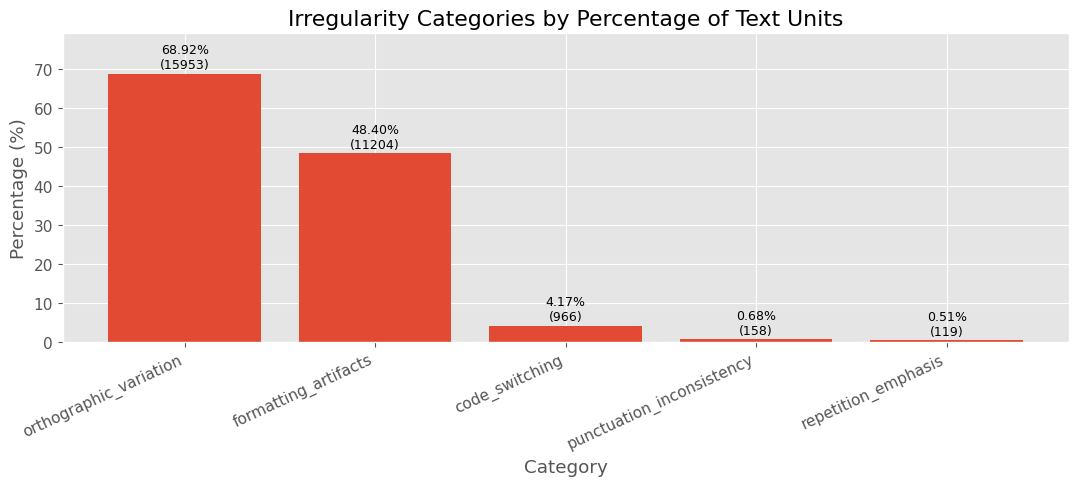

Saved: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\figures\ms1_irregularity_category_percentages.png


In [9]:
categories = [row["category"] for row in frequency_table]
counts = [row["count"] for row in frequency_table]
percentages = [row["percentage"] for row in frequency_table]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(categories, percentages)
ax.set_title("Irregularity Categories by Percentage of Text Units")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Category")
ax.set_ylim(0, max(percentages) * 1.15)

for index, value in enumerate(percentages):
    ax.text(
        index,
        value + 0.6,
        f"{value:.2f}%\n({counts[index]})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
output_file = figures_dir / "ms1_irregularity_category_percentages.png"
plt.savefig(output_file, dpi=150)
plt.show()

print(f"Saved: {output_file}")

## Signal Breakdown for Code-Switching and Punctuation

These plots show which sub-signals are responsible for each category.

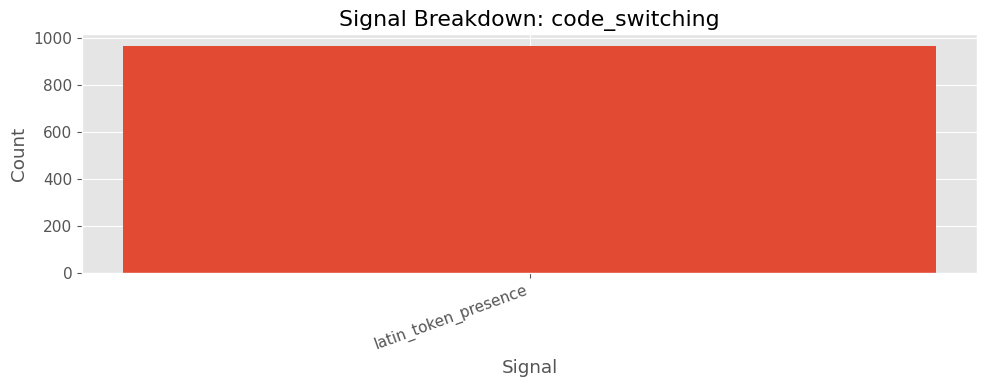

Saved: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\figures\ms1_code_switching_signals.png


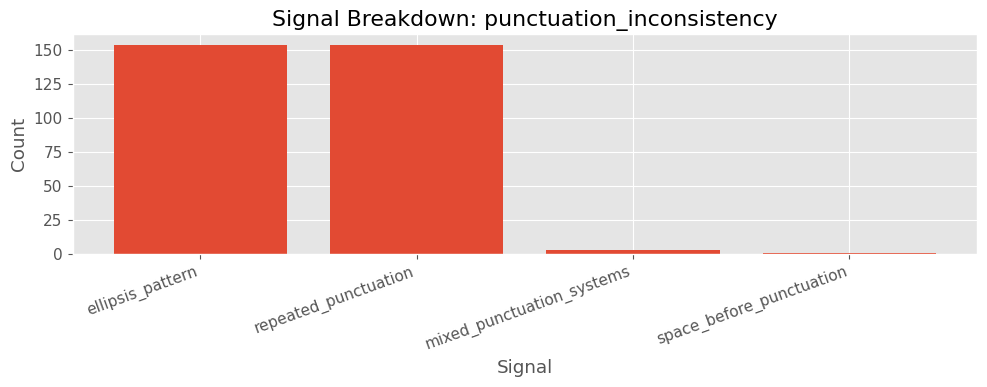

Saved: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\figures\ms1_punctuation_inconsistency_signals.png


In [10]:
def plot_signal_breakdown(category_name: str) -> None:
    signals = category_details[category_name]["signal_breakdown"]
    labels = list(signals.keys())
    values = list(signals.values())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, values)
    ax.set_title(f"Signal Breakdown: {category_name}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Signal")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    output_file = figures_dir / f"ms1_{category_name}_signals.png"
    plt.savefig(output_file, dpi=150)
    plt.show()
    print(f"Saved: {output_file}")


plot_signal_breakdown("code_switching")
plot_signal_breakdown("punctuation_inconsistency")

## Example Inspection

Print representative examples for code-switching and punctuation inconsistency.

In [11]:
def print_examples(category_name: str, max_rows: int = 5) -> None:
    print(f"\n=== {category_name} ===")
    examples = category_details[category_name]["examples"][:max_rows]
    for index, example in enumerate(examples, start=1):
        line_number = example.get("line_number")
        location = f"{example['video_id']} | {example['source_file']}"
        if line_number is not None:
            location = f"{location} | line {line_number}"

        print(f"{index}. signal={example['signal']}")
        print(f"   reason={example['reason']}")
        print(f"   location={location}")
        print(f"   excerpt={example['excerpt']}")


print_examples("code_switching")
print_examples("punctuation_inconsistency")


=== code_switching ===
1. signal=latin_token_presence
   reason=Latin token(s) detected: F-35
   location=أعظم طائرة حربية  الدحيح | أعظم طائرة حربية  الدحيح.txt | line 7
   excerpt=12.205: الـF-35.
2. signal=latin_token_presence
   reason=Latin token(s) detected: Target
   location=أعظم طائرة حربية  الدحيح | أعظم طائرة حربية  الدحيح.txt | line 21
   excerpt=تـTarget أطفال بالتحديد يعني...
3. signal=latin_token_presence
   reason=Latin token(s) detected: Model
   location=أعظم طائرة حربية  الدحيح | أعظم طائرة حربية  الدحيح.txt | line 35
   excerpt=63.501: اللي هو بيفكر يشتري الـModel دا يعني.
4. signal=latin_token_presence
   reason=Latin token(s) detected: Sensor
   location=أعظم طائرة حربية  الدحيح | أعظم طائرة حربية  الدحيح.txt | line 50
   excerpt=89.125: هل فيها Sensor رَكنة؟
5. signal=latin_token_presence
   reason=Latin token(s) detected: Sensor
   location=أعظم طائرة حربية  الدحيح | أعظم طائرة حربية  الدحيح.txt | line 51
   excerpt=91.081: Sensor رَكنة؟!

=== punctuation_incon

## Top Latin Tokens (Why Code-Switching Happens)

Count the most frequent Latin-script tokens across transcripts and QA text.

Top Latin tokens:
- f-35: 78
- hangar: 32
- the: 32
- cult: 28
- actually: 23
- of: 22
- kane: 16
- citizen: 15
- streltsy: 14
- seppuku: 13
- block: 12
- entropy: 11
- fbi: 9
- game: 8
- r3: 8


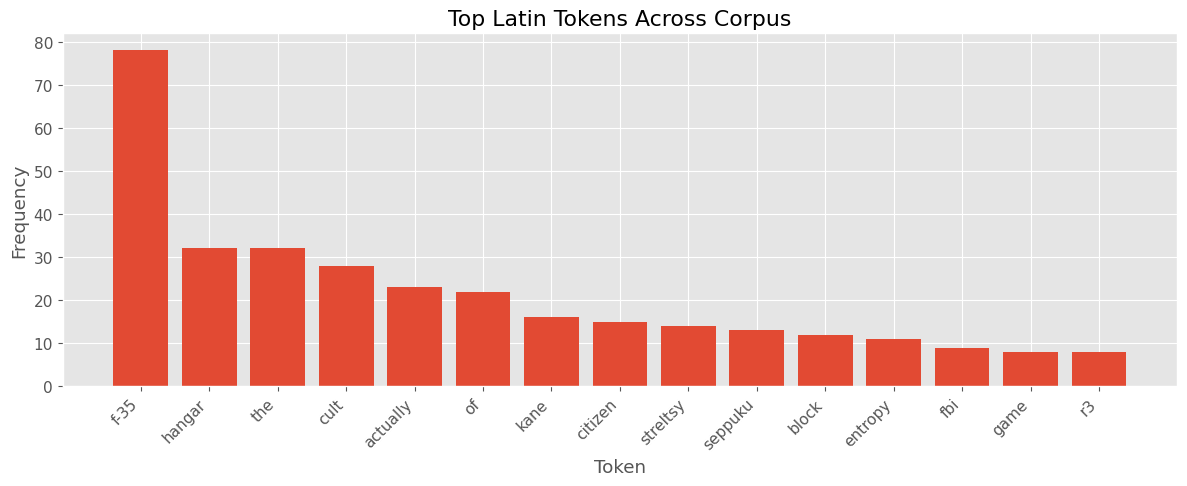

Saved: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\figures\ms1_code_switching_top_latin_tokens.png


In [12]:
from src.ms1.ingest.loader import load_qa_files, load_transcripts

latin_token_re = re.compile(r"[A-Za-z][A-Za-z0-9_\-/]*")
latin_counter: Counter[str] = Counter()

transcripts = load_transcripts(paths)
qa_records = load_qa_files(paths)

for transcript in transcripts:
    latin_counter.update(
        token.lower() for token in latin_token_re.findall(transcript["content"])
    )

for row in qa_records:
    text = f"{row.get('question', '')} {row.get('answer', '')}"
    latin_counter.update(token.lower() for token in latin_token_re.findall(text))

most_common_tokens = latin_counter.most_common(15)
print("Top Latin tokens:")
for token, count in most_common_tokens:
    print(f"- {token}: {count}")

labels = [item[0] for item in most_common_tokens]
values = [item[1] for item in most_common_tokens]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, values)
ax.set_title("Top Latin Tokens Across Corpus")
ax.set_ylabel("Frequency")
ax.set_xlabel("Token")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
output_file = figures_dir / "ms1_code_switching_top_latin_tokens.png"
plt.savefig(output_file, dpi=150)
plt.show()

print(f"Saved: {output_file}")

## Interpretation Notes (for Report)

Use the outputs above to justify findings:

- **Code-switching** is mostly domain borrowing (e.g., model names, institutions, technical terms).
- **Punctuation inconsistency** is mostly ellipsis-style conversational pausing and transcription artifacts.
- Mixed Arabic/Latin punctuation and spacing-before-punctuation exist but are relatively rare.

You can copy these points into your milestone report and refine with the plotted values.

## Export Insights to Summary Markdown

This cell writes a marker-based auto-generated insights block into `experiments/ms1/irregularity_summary.md` so report notes stay reproducible.

In [13]:
from datetime import datetime

INSIGHTS_START = "<!-- AUTO-INSIGHTS-START -->"
INSIGHTS_END = "<!-- AUTO-INSIGHTS-END -->"


def _replace_or_append_block(
    document: str, start_marker: str, end_marker: str, block: str
) -> str:
    if start_marker in document and end_marker in document:
        start_index = document.index(start_marker)
        end_index = document.index(end_marker) + len(end_marker)
        before = document[:start_index].rstrip()
        after = document[end_index:].lstrip("\n")
        return f"{before}\n\n{block}\n\n{after}".rstrip() + "\n"

    base = document.rstrip()
    return f"{base}\n\n{block}\n"


if "summary_path" not in globals():
    from src.common.paths import resolve_ms1_paths

    paths = resolve_ms1_paths(repo_root=project_root)
    summary_path = paths.experiments_ms1 / "irregularity_summary.md"

if "frequency_table" not in globals() or "category_details" not in globals():
    if "report" not in globals():
        with open(report_path, "r", encoding="utf-8") as file_handle:
            report = json.load(file_handle)
    frequency_table = report["frequency_table"]
    category_details = report["category_details"]

if not summary_path.exists():
    raise FileNotFoundError(f"Summary file not found: {summary_path}")

frequency_lookup = {row["category"]: row for row in frequency_table}
code_row = frequency_lookup.get("code_switching", {"count": 0, "percentage": 0.0})
punct_row = frequency_lookup.get(
    "punctuation_inconsistency", {"count": 0, "percentage": 0.0}
)

punct_signals = category_details.get("punctuation_inconsistency", {}).get(
    "signal_breakdown", {}
)
sorted_punct_signals = sorted(
    punct_signals.items(), key=lambda item: (-item[1], item[0])
)
top_punct_signals = ", ".join(
    [f"{name} ({count})" for name, count in sorted_punct_signals[:3]]
)
if not top_punct_signals:
    top_punct_signals = "N/A"

if "most_common_tokens" not in globals():
    most_common_tokens = []
top_tokens_str = ", ".join(
    [f"{token} ({count})" for token, count in most_common_tokens[:5]]
)
if not top_tokens_str:
    top_tokens_str = "N/A"

insight_lines = [
    "## Insights Addendum (Auto-Generated)",
    "",
    f"- Generated from notebook on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"- Code-switching affects **{code_row['percentage']:.2f}%** of analyzed text units (**{code_row['count']}** units).",
    f"- Dominant Latin-token drivers (top 5): {top_tokens_str}.",
    f"- Punctuation inconsistency affects **{punct_row['percentage']:.2f}%** of analyzed text units (**{punct_row['count']}** units).",
    f"- Dominant punctuation signals: {top_punct_signals}.",
    "- Interpretation: most punctuation flags come from conversational ellipses/repetition, while mixed punctuation systems and spacing artifacts are rare.",
]

auto_block = f"{INSIGHTS_START}\n" + "\n".join(insight_lines) + f"\n{INSIGHTS_END}"

original_summary = summary_path.read_text(encoding="utf-8")
updated_summary = _replace_or_append_block(
    original_summary, INSIGHTS_START, INSIGHTS_END, auto_block
)
summary_path.write_text(updated_summary, encoding="utf-8")

print(f"Updated summary: {summary_path}")
print("Inserted/updated block markers:", INSIGHTS_START, INSIGHTS_END)

Updated summary: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\irregularity_summary.md
Inserted/updated block markers: <!-- AUTO-INSIGHTS-START --> <!-- AUTO-INSIGHTS-END -->
